# SAMI · Notebook 2 — Demand, behaviour & experience

**Mandate (Acts 2–3, quantitative).** What are people asking the bot, how does that
demand move across cities and weeks, how far does engagement carry, and how satisfied
are the few who tell us? Every figure carries an assertion-evidence title, its metric,
its n, and the observation window; every number traces to the P10 reconciliation table
reproduced at the top and bottom of this notebook. Modules compute, this notebook
consumes — no analytical logic lives in a cell.

> **Grain note.** Messages inherit the timestamp of their response record (there is no
> per-message timestamp). All weekly and daily trends are therefore at
> **record-arrival granularity**, not true per-message time.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sami import load_sami, stats, metrics, taxonomy, theme, canon

CAT_ORDER = taxonomy.OFFICIAL_CATEGORIES + ["unclassified"]
CAT_COLOR = dict(zip(CAT_ORDER, theme.bar_colors(len(CAT_ORDER))))
CAT_EN = {  # EN display for category labels (chart text only)
    "legal_documentation": "Legal & documentation",
    "humanitarian_assistance": "Humanitarian assistance",
    "protection": "Protection",
    "employment": "Employment",
    "organization_search": "Finding organizations",
    "journey_information": "Journey information",
    "services": "Services",
    "unclassified": "Unclassified",
}
SD = load_sami()
WINDOW = f"{SD.run_meta['ts_min'][:10]} → {SD.run_meta['ts_max'][:10]}"


In [2]:
print("Source:", SD.run_meta["responses_file"], "|", SD.run_meta["responses_rows"], "rows |", WINDOW)
recon_top = SD.reconciliation.copy()
recon_top


Source: MMC_bot_responses_1783087815.xlsx | 948 rows | 2026-03-25 → 2026-07-03


,metric,value
0,users,917
1,records,946
2,messages,2991
3,users_with_text,800
4,meal_responses,69
5,meal_response_rate_pct,7.5
6,legal_documentation_pct,51.7
7,repeat_askers_pct,11.9
8,negative_tone_pct,pending


## 1 · Demand mix

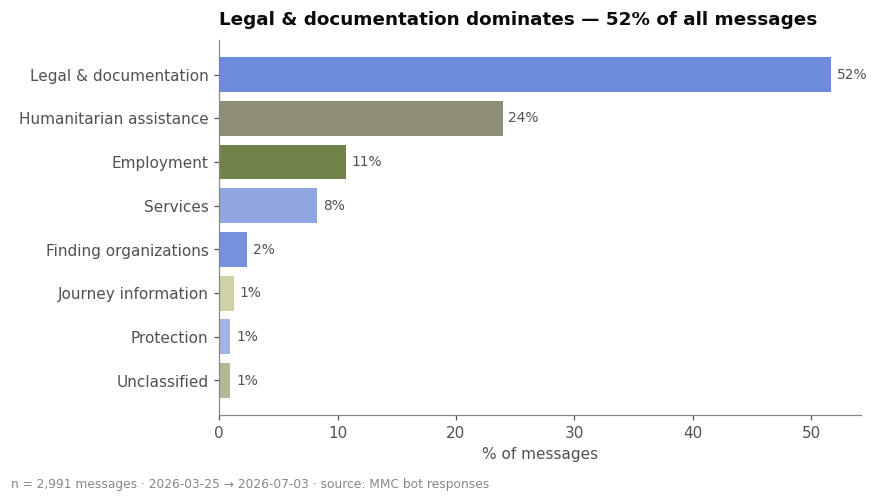

In [3]:
share = metrics.category_share(SD.messages).rename(index=CAT_EN)
fig, ax = plt.subplots(figsize=(8, 4.4))
colors = [CAT_COLOR[k] for k in metrics.category_share(SD.messages).index]
ax.barh(share.index[::-1], (share.values * 100)[::-1], color=colors[::-1])
for y, v in enumerate((share.values * 100)[::-1]):
    ax.text(v + 0.5, y, f"{v:.0f}%", va="center", fontsize=9, color=theme.INK2)
ax.set_xlabel("% of messages")
ax.set_title(f"Legal & documentation dominates — {share.iloc[0]*100:.0f}% of all messages")
ax.set_ylabel("")
n = len(SD.messages)
fig.text(0.01, -0.02, f"n = {n:,} messages · {WINDOW} · source: MMC bot responses", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


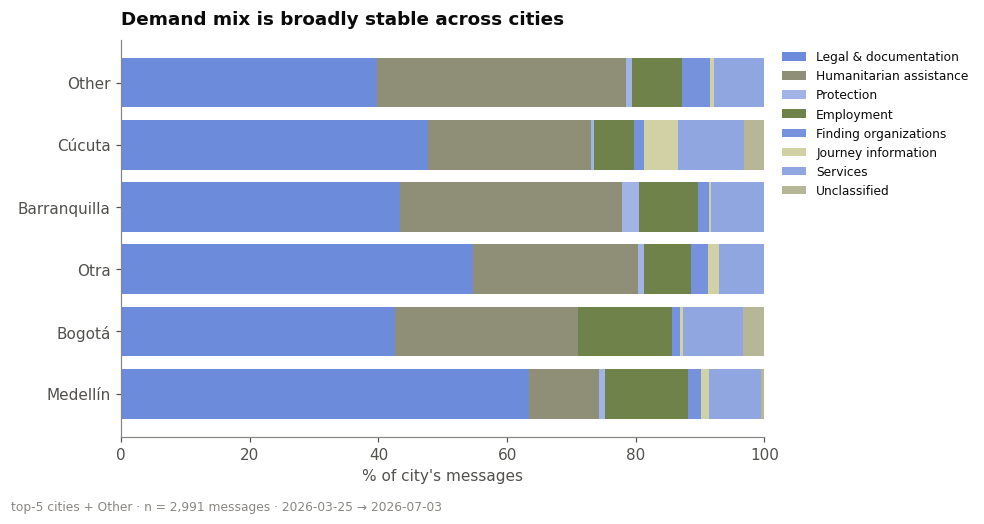

In [4]:
mix = metrics.city_category_mix(SD.messages, top_cities=5)
mix_en = mix.rename(columns=CAT_EN)
fig, ax = plt.subplots(figsize=(9, 4.6))
left = np.zeros(len(mix_en))
for cat in [c for c in CAT_ORDER if CAT_EN[c] in mix_en.columns]:
    vals = mix_en[CAT_EN[cat]].values * 100
    ax.barh(mix_en.index, vals, left=left, color=CAT_COLOR[cat], label=CAT_EN[cat])
    left += vals
ax.set_xlabel("% of city's messages"); ax.set_ylabel("")
ax.set_title("Demand mix is broadly stable across cities")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
fig.text(0.01, -0.02, f"top-5 cities + Other · n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


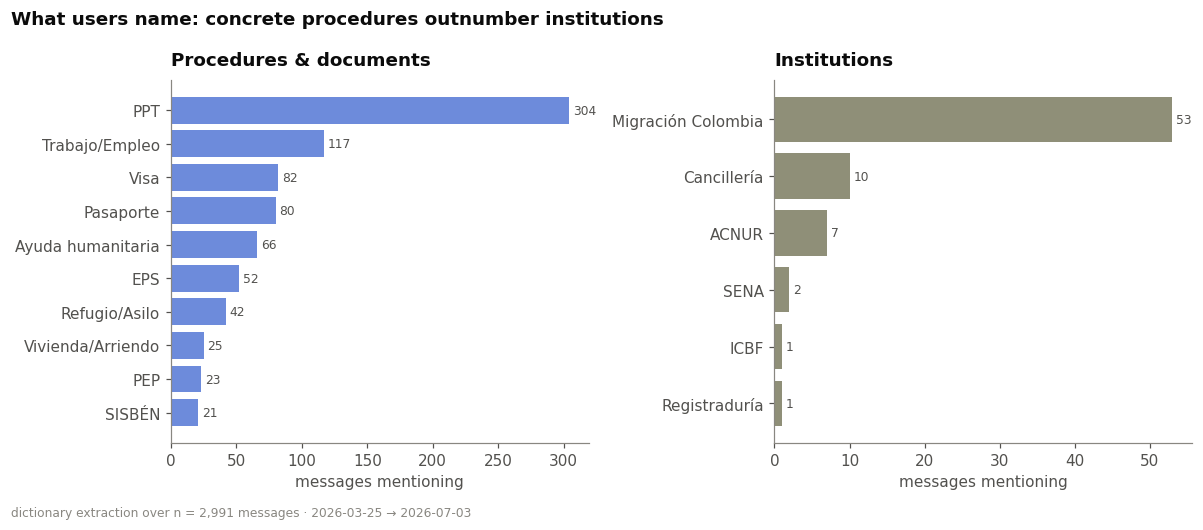

In [5]:
by_kind = taxonomy.entity_counts_by_kind(SD.messages["message"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, kind, title in [(axes[0], "procedure", "Procedures & documents"),
                        (axes[1], "institution", "Institutions")]:
    s = by_kind[kind].head(10)
    ax.barh(s.index[::-1], s.values[::-1], color=theme.PRIMARY if kind=="procedure" else theme.MADERA)
    for y, v in enumerate(s.values[::-1]):
        ax.text(v + max(s.values)*0.01, y, str(int(v)), va="center", fontsize=8, color=theme.INK2)
    ax.set_title(title); ax.set_xlabel("messages mentioning")
axes[0].figure.suptitle("What users name: concrete procedures outnumber institutions", x=0.01, ha="left", fontsize=12, weight="semibold")
fig.text(0.01, -0.02, f"dictionary extraction over n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


## 2 · Demand over time  (record-arrival grain — see note above)

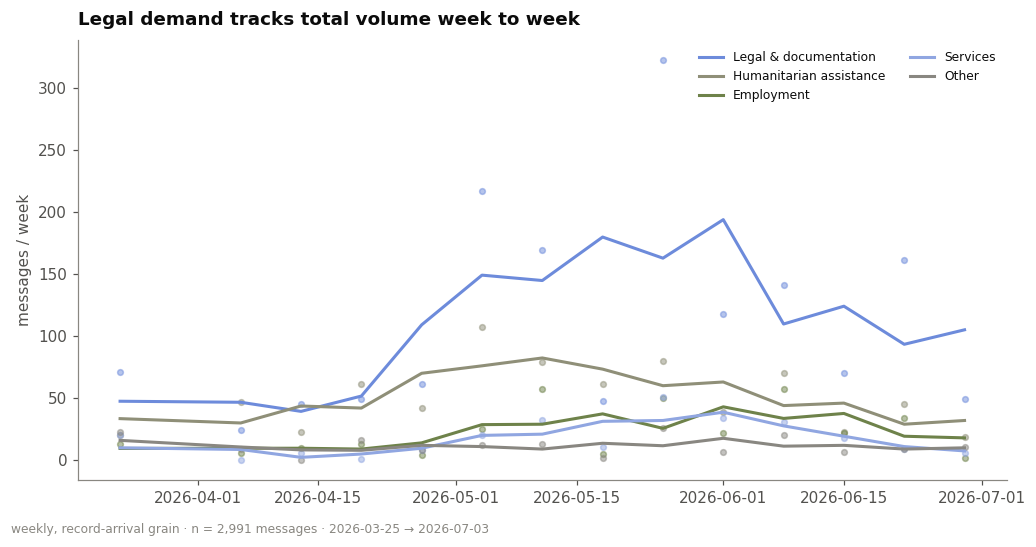

In [6]:
wk = metrics.weekly_category_counts(SD.messages, top_n=4)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for cat in wk.columns:
    color = CAT_COLOR.get(cat, theme.MUTED)
    x = wk.index; y = wk[cat].values
    ax.scatter(x, y, s=14, color=color, alpha=0.5)                # raw points
    ax.plot(x, pd.Series(y, index=x).rolling(3, center=True, min_periods=1).mean(),
            color=color, lw=2, label=CAT_EN.get(cat, cat))        # smoothed spline
ax.set_ylabel("messages / week"); ax.set_xlabel("")
ax.set_title("Legal demand tracks total volume week to week")
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.text(0.01, -0.02, f"weekly, record-arrival grain · n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


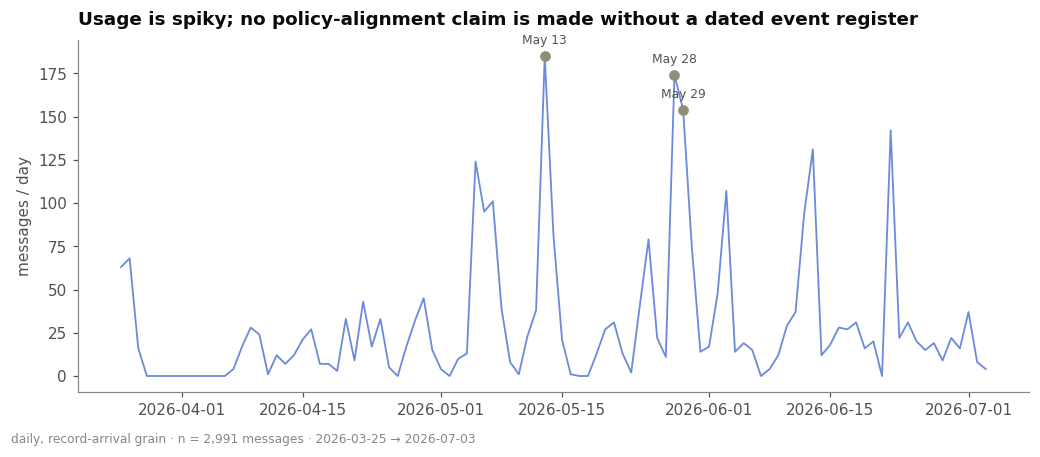

In [7]:
daily = SD.messages.dropna(subset=["ts"]).set_index("ts").resample("D").size()
fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.plot(daily.index, daily.values, color=theme.PRIMARY, lw=1.2)
top_days = daily.nlargest(3)
for d, v in top_days.items():
    ax.annotate(d.strftime("%b %d"), (d, v), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color=theme.INK2)
    ax.scatter([d], [v], color=theme.MADERA, zorder=5)
ax.set_ylabel("messages / day"); ax.set_title("Usage is spiky; no policy-alignment claim is made without a dated event register")
fig.text(0.01, -0.02, f"daily, record-arrival grain · n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


## 3 · Cross-cuts that earned their place

A cross-cut is shown **only if** its association is both statistically significant *and* carries a non-trivial effect size (Cramér's V ≥ 0.1) on a table where the chi-square approximation is valid (min expected cell ≥ 5). Otherwise it is reported directionally in one line and the figure is dropped — detectable-but-trivial is not a finding.

In [8]:
def show_or_state(a, b, title, xlabel, ylabel, render):
    """Render a cross-cut only if the association is statistically meaningful."""
    res = stats.assoc_test(a, b)
    tag = f"V={res['cramers_v']:.2f}, p={res['p']:.3f}, {res['test']}, n={res['n']}"
    if res["meaningful"]:
        render(res, tag)
    else:
        print(f"[no meaningful difference] {title}: {tag} — reported directional-only, figure dropped.")
    return res


In [9]:
# Settlement duration x city — restricted to the well-populated cities so the
# chi-square table is valid (the full 13-city table is >60% sparse cells, which
# inflates V into a spurious 0.25; on adequately-sized cells the effect is trivial).
resp = SD.responses.dropna(subset=["city_duration_canon", "city_canon"])
resp = resp[resp["city_canon"] != "Otra"]
_top_dur_cities = list(resp["city_canon"].value_counts().head(6).index)
resp = resp[resp["city_canon"].isin(_top_dur_cities)]
def _render_dur_city(res, tag):
    ct = pd.crosstab(resp["city_canon"], resp["city_duration_canon"],
                     normalize="index").reindex(columns=canon.CITY_DURATION_ORDER)
    fig, ax = plt.subplots(figsize=(9, 4.6))
    left = np.zeros(len(ct))
    for i, dur in enumerate(canon.CITY_DURATION_ORDER):
        if dur not in ct.columns: continue
        vals = ct[dur].fillna(0).values * 100
        ax.barh(ct.index, vals, left=left, color=theme.seq_colors(len(canon.CITY_DURATION_ORDER))[i], label=dur)
        left += vals
    ax.set_title(f"Settlement time differs by city ({tag})")
    ax.set_xlabel("% of city's users"); ax.legend(fontsize=7, frameon=False, bbox_to_anchor=(1.01,1), loc="upper left")
    fig.text(0.01, -0.02, f"n = {res['n']} users with both fields · {WINDOW}", fontsize=8, color=theme.MUTED)
    plt.tight_layout(); plt.show()
show_or_state(resp["city_canon"], resp["city_duration_canon"],
              "duration × city (top-6 cities)", "city", "settlement time", _render_dur_city)


[no meaningful difference] duration × city (top-6 cities): V=0.09, p=0.005, chi2, n=683 — reported directional-only, figure dropped.


{'stat': 39.90874655971536,
 'p': 0.005129779662245403,
 'dof': 20,
 'test': 'chi2',
 'cramers_v': 0.08555371230447352,
 'min_expected': 2.281112737920937,
 'n': 683,
 'meaningful': False}

In [10]:
gn = SD.responses.copy()
gn = gn[gn["gender_clean"].isin(["Mujer", "Hombre"]) & gn["nationality_canon"].isin(["Venezuela", "Ecuador", "Peru", "Colombia"])]
def _render_gender_nat(res, tag):
    ct = pd.crosstab(gn["nationality_canon"], gn["gender_clean"].map(canon.GENDER_DISPLAY), normalize="index")
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ct.plot(kind="barh", ax=ax, color=theme.cat_colors(ct.shape[1]))
    ax.set_title(f"Gender split varies by nationality ({tag})"); ax.set_xlabel("share")
    fig.text(0.01, -0.02, f"n = {res['n']} users · {WINDOW}", fontsize=8, color=theme.MUTED)
    plt.tight_layout(); plt.show()
show_or_state(gn["nationality_canon"], gn["gender_clean"],
              "gender × nationality", "nationality", "gender", _render_gender_nat)


[no meaningful difference] gender × nationality: V=0.04, p=0.224, chi2, n=907 — reported directional-only, figure dropped.


{'stat': 4.375573519694512,
 'p': 0.22366100463686564,
 'dof': 3,
 'test': 'chi2',
 'cramers_v': 0.03891837744401466,
 'min_expected': 0.6912899669239251,
 'n': 907,
 'meaningful': False}

> The **age × destination** cut is intentionally omitted: cells are n ≤ 6, below any reliable test threshold (methodology doc 02 §5). Reporting it would invite over-reading of noise.